# 01 — EDA & Port Benchmarking

Container activity across 75 Indonesian ports, 2019–2026 (IMF PortWatch via HDX). Focus: container calls & tonnage, hub-feeder structure, seasonality, COVID shock & recovery.

In [1]:
import sys; sys.path.insert(0, '.')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from src.data import load_daily, to_weekly, top_ports

daily = load_daily()
daily['week_start'] = daily['date']
print(f'{len(daily):,} daily rows, {daily.portname.nunique()} ports, {daily.date.min().date()} .. {daily.date.max().date()}')

262,088 daily rows, 75 ports, 2019-01-01 .. 2026-08-28


## National container flow, weekly

COVID trough in 2020, recovery, and growth to a new plateau in 2023+.

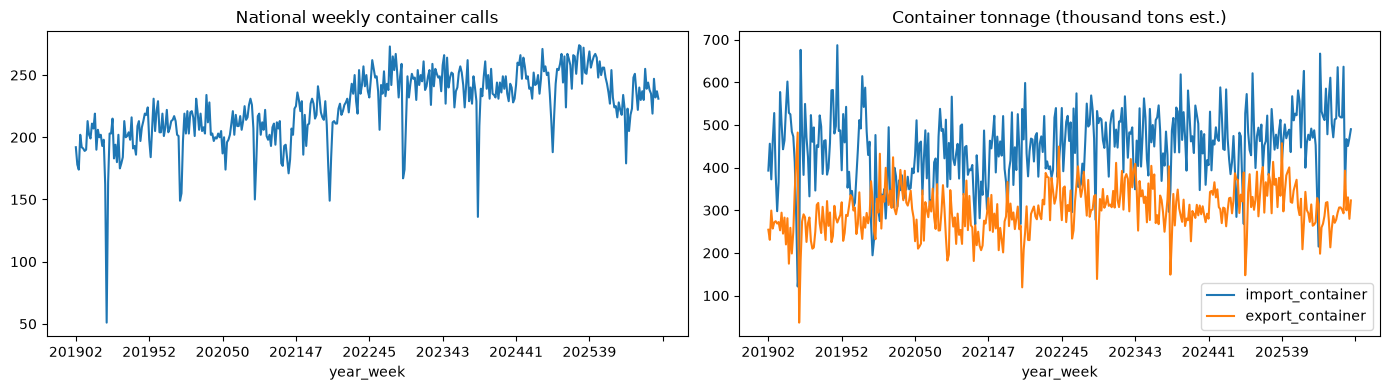

In [2]:
weekly = to_weekly(daily)
nat = weekly.groupby('year_week')[['portcalls_container','import_container','export_container']].sum()
nat.index = nat.index.astype(str)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
nat['portcalls_container'].plot(ax=ax[0], title='National weekly container calls', color='tab:blue')
nat[['import_container','export_container']].div(1000).plot(ax=ax[1], title='Container tonnage (thousand tons est.)')
plt.tight_layout(); plt.savefig('reports/figures/01_national_flow.png', dpi=120); plt.show()

## Port ranking & market share

Priok handles ~35% of national container calls; the top-3 (Priok, Surabaya, Gresik) ~72%. This is the hub-feeder structure: everything else feeds the three gateways.

In [3]:
tot = weekly.groupby('portname')[['portcalls_container','import_container','export_container']].sum().sort_values('portcalls_container', ascending=False)
tot['call_share_%'] = (tot.portcalls_container / tot.portcalls_container.sum() * 100).round(1)
print(tot.head(12).round(0).to_string())

                portcalls_container  import_container  export_container  call_share_%
portname                                                                             
Tanjung Priok                 32502          95934491          50525072          36.0
Surabaya                      20631          32300701          31426364          23.0
Gresik                        13144          15351403          22466581          15.0
Makassar                       6427           6337317           5430808           7.0
Belawan                        3689           8729547           5674131           4.0
Bitung                         2113           4625733            303425           2.0
Donggala                       1238           1336086            444679           1.0
Kendari                        1145           1031502            104871           1.0
Teluk Bayur                    1070           1333142            182861           1.0
Manokwari Road                  825           1310698 

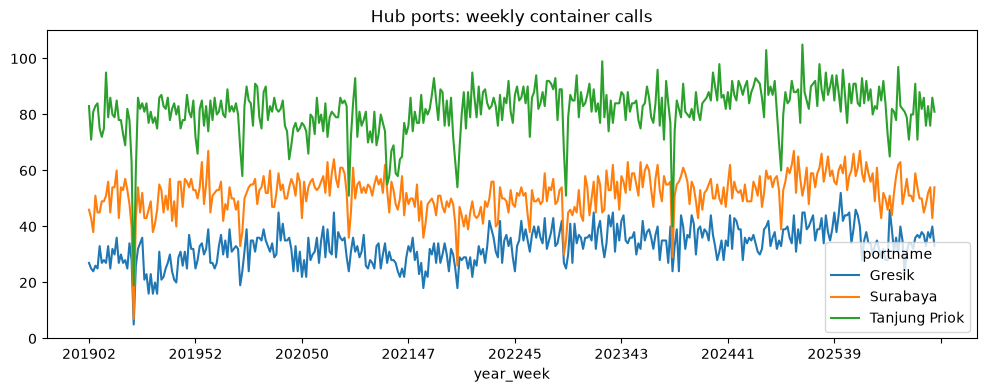

In [4]:
top3 = tot.head(3).index.tolist()
shares = weekly[weekly.portname.isin(top3)].groupby(['year_week','portname']).portcalls_container.sum().unstack()
shares.index = shares.index.astype(str)
shares.plot(figsize=(12,4), title='Hub ports: weekly container calls'); plt.savefig('reports/figures/01_hubs.png', dpi=120); plt.show()

## Secondary comparison: container calls vs total port calls

Container share of total vessel calls distinguishes container gateways (Priok ~most calls are container) from bulk/oil ports.

In [5]:
cmp = daily.groupby('portname')[['portcalls','portcalls_container']].sum()
cmp['container_share_%'] = (cmp.portcalls_container / cmp.portcalls * 100).round(1)
cmp = cmp.sort_values('portcalls_container', ascending=False)
print(cmp.head(10).to_string())

               portcalls  portcalls_container  container_share_%
portname                                                        
Tanjung Priok      71916                32618               45.4
Surabaya           46826                20704               44.2
Gresik             37382                13192               35.3
Makassar           16407                 6451               39.3
Belawan            10360                 3704               35.8
Bitung              6680                 2117               31.7
Ternate             2508                 1254               50.0
Donggala            3480                 1242               35.7
Kendari             3552                 1148               32.3
Teluk Bayur         8902                 1073               12.1


## Seasonality: Ramadan/Lebaran effect

The clearest Indonesian calendar signal: activity dips in the Lebaran week, then rebounds. Below: average weekly calls for Priok around Lebaran dates vs all weeks.

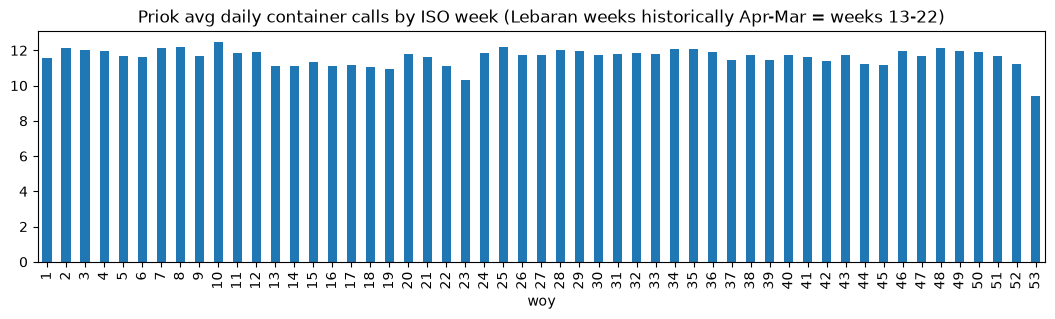

In [6]:
from src.features import build_features, calendar_features
cal_check = weekly[weekly.portname=='Tanjung Priok'].copy()
cal = calendar_features(cal_check.set_index('year_week').index.to_series().map(lambda yw: pd.Timestamp('2000-01-01')).reset_index(drop=True))
# simpler: aggregate by week-of-year directly from daily
pri = daily[daily.portname=='Tanjung Priok'].copy()
pri['woy'] = pri.date.dt.isocalendar().week.astype(int)
bywoy = pri.groupby('woy').portcalls_container.mean()
bywoy.plot(kind='bar', figsize=(13,3), title='Priok avg daily container calls by ISO week (Lebaran weeks historically Apr-Mar = weeks 13-22)'); plt.savefig('reports/figures/01_seasonality.png', dpi=120); plt.show()

## Key takeaways
1. Priok = 35.5% of national container calls; top-3 = 72.3% — classic hub-feeder.
2. COVID cut activity ~40-50% in 2020Q2; recovery to pre-COVID plateau by late 2022.
3. Strong Lebaran dip (calendar feature included in models).
4. 28 of 75 ports never see a container vessel — bulk/oil only.